In [1]:
import pandas as pd
import numpy as np
from matplotlib_venn import venn2
import seaborn as sns
from mpralib.mpradata import MPRABarcodeData
from mpralib.mpradata import Modality
import mpralib.utils.plot
from mpralib.utils.plot import dna_vs_rna, barcodes_per_oligo
from mpralib.utils.plot import correlation
from mpralib.mpradata import BarcodeFilter
from mpralib.utils.io import export_activity_file
from mpralib.utils.io import export_barcode_file
from scipy.stats import spearmanr, pearsonr
from copy import deepcopy

import scripts.barcode_processing as barcode_processing
import scripts.plotting as plotting
import scripts.element_analysis as element_analysis

# Element Barcode Filter Notebook

### Load MPRAsnakeflow table

#### In this example I use MPRAsnakeflow Data from NGN2 and WTC11 Celltypes

In [18]:
df_NGN2 = pd.read_table('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
df_WTC11 = pd.read_table('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

### Load MPRAsnakeflow data in MPRAlib

In [19]:
NGN2 = MPRABarcodeData.from_file('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
WTC11 = MPRABarcodeData.from_file('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

### Load the merged and enhanced Element data (its a combination from the MPRAsnakeflow data with the Bcalm data combined over the given celltypes)

In [20]:
#element_merge = pd.read_table('data/results/merge_elements/element_merge.tsv.gz')

#### Filter the Dataset with the MPRAlib (it doesn't remove the Barcode outliers)

In [21]:
NGN2_filtered_bc_10_z_3 = barcode_processing.barcode_filter(element_threshold_filtered = NGN2,
                                         threshold = 10,
                                         z_score = 3)
WTC11_filtered_bc_10_z_3 = barcode_processing.barcode_filter(element_threshold_filtered = WTC11,
                                          threshold = 10,
                                          z_score = 3)



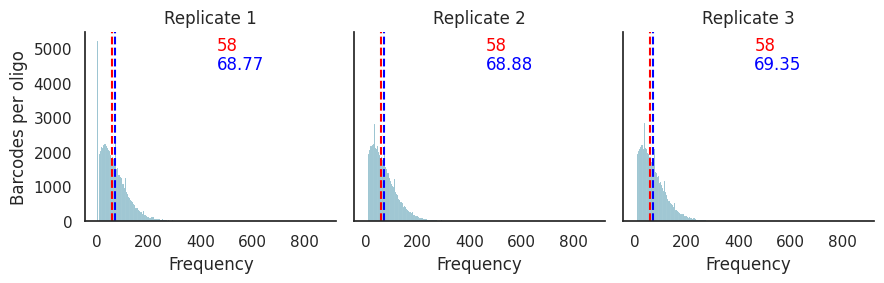

In [22]:
mpralib.utils.plot.barcodes_per_oligo(NGN2_filtered_bc_10_z_3.oligo_data)

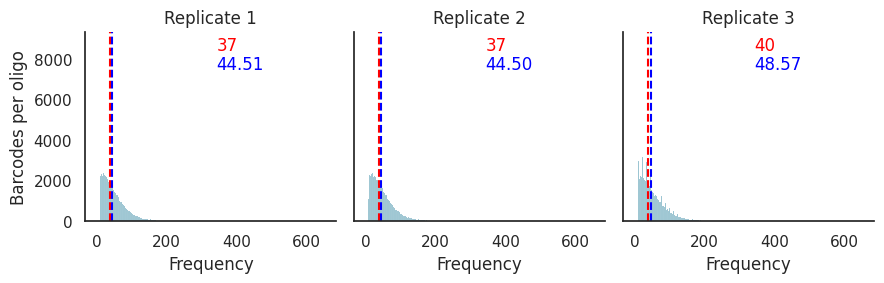

In [23]:
mpralib.utils.plot.barcodes_per_oligo(WTC11_filtered_bc_10_z_3.oligo_data)

#### Get the normalized DNA and RNA counts

In [24]:
NGN2_norm_bc_10_z_3 = barcode_processing.get_normalized_dna_rna_counts(element_filtered = NGN2_filtered_bc_10_z_3)
WTC11_norm_bc_10_z_3 = barcode_processing.get_normalized_dna_rna_counts(element_filtered = WTC11_filtered_bc_10_z_3)

In [25]:
NGN2_norm_bc_10_z_3.head()

,DNA_norm_1,DNA_norm_2,DNA_norm_3,RNA_norm_1,RNA_norm_2,RNA_norm_3
barcode,,,,,,
ACGAGGGGTTTGCTC,0.000000,0.114577,0.075492,0.000000,0.047915,0.061881
CAGATCGGTTGATTC,0.235082,0.267347,0.113238,0.164364,0.095830,0.185643
CTGTTGGTCTATACG,0.078361,0.114577,0.075492,0.134479,0.063886,0.092821
GATTCGAATGTGTGG,0.235082,0.267347,0.339713,0.224132,0.239574,0.262994
ACTTAGTTGTCTCTT,0.117541,0.114577,0.075492,0.044826,0.031943,0.046411


#### Mapping to every barcode the fitting oligo

In [ ]:
NGN2_map_bc_10_z_3 = barcode_processing.map_oligo_to_barcode(
                                filter_normalize_data = NGN2_norm_bc_10_z_3,
                                barcode_data = df_NGN2)
WTC11_map_bc_10_z_3 = barcode_processing.map_oligo_to_barcode(WTC11_norm_bc_10_z_3,
                                df_WTC11)

#### Filter oligos by minimum barcode count and save current dataset

In [27]:
NGN2_bc_10_z_3 = barcode_processing.threshold_filter(
                    data_table = NGN2_map_bc_10_z_3.reset_index(),
                    threshold = 10)
NGN2_bc_10_z_3.to_csv('data/results/barcode_thresholds/NGN2_bc_10_z_3.tsv.gz',
                        sep = '\t',
                        index = False)

WTC11_bc_10_z_3 =barcode_processing.threshold_filter(
                    data_table = WTC11_map_bc_10_z_3.reset_index(),
                    threshold = 10)
WTC11_bc_10_z_3.to_csv('data/results/barcode_thresholds/WTC11_bc_10_z_3.tsv.gz',
                        sep = '\t',
                        index = False)

#### Load the the dataset with normalised barcodes and filtered barcode counts

In [1]:
import pandas as pd
import scripts.barcode_processing as barcode_processing
import scripts.plotting as plotting
import scripts.element_analysis as element_analysis

NGN2_bc_10_z_3 = pd.read_table('data/results/barcode_thresholds/NGN2_bc_10_z_3.tsv.gz')
WTC11_bc_10_z_3 = pd.read_table('data/results/barcode_thresholds/WTC11_bc_10_z_3.tsv.gz')

#### Calculate the effect size for every replicate

In [2]:
NGN2_calculate_effect_size_bc_10_z_3 = barcode_processing.calculate_effect_size_per_replicate(NGN2_bc_10_z_3)
WTC11_calculate_effect_size_bc_10_z_3 = barcode_processing.calculate_effect_size_per_replicate(WTC11_bc_10_z_3)

In [4]:
NGN2_barcodes_per_oligo_bc_10_z_3 = barcode_processing.count_barcodes_per_oligo(
    oligo_per_barcode_table = NGN2_calculate_effect_size_bc_10_z_3
)
WTC11_barcodes_per_oligo_bc_10_z_3 = barcode_processing.count_barcodes_per_oligo(
    oligo_per_barcode_table = WTC11_calculate_effect_size_bc_10_z_3
)

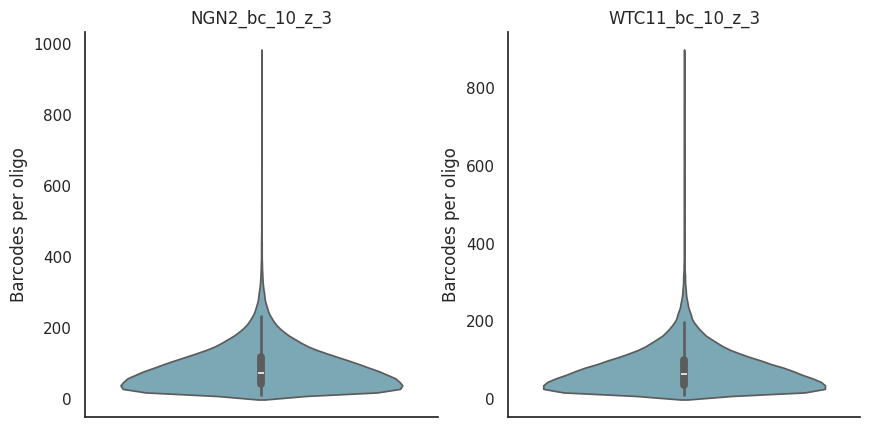

In [ ]:
plotting.plot_barcode_per_oligo(
    barcode_per_oligo_tabels = [NGN2_barcodes_per_oligo_bc_10_z_3,
                                WTC11_barcodes_per_oligo_bc_10_z_3],
    cell_names = ['NGN2_bc_10_z_3', 'WTC11_bc_10_z_3'])

In [3]:
NGN2_reshape_effect_size_bc_10_z_3 = element_analysis.effect_sizes_long(NGN2_calculate_effect_size_bc_10_z_3)
WTC11_reshape_effect_size_bc_10_z_3 = element_analysis.effect_sizes_long(WTC11_calculate_effect_size_bc_10_z_3)

In [4]:
NGN2_oligo_effect_stats_bc_10_z_3 = element_analysis.rename_aggregate_columns(
    aggregate_tabel = element_analysis.aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_10_z_3),
    cell_type = 'NGN2')
WTC11_oligo_effect_stats_bc_10_z_3 = element_analysis.rename_aggregate_columns(
    aggregate_tabel = element_analysis.aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_10_z_3),
    cell_type = 'WTC11')

In [5]:
NGN2_WTC11_oligo_effect_stats_bc_10_z_3 = element_analysis.merge_aggregate_tables([NGN2_oligo_effect_stats_bc_10_z_3, 
                                                    WTC11_oligo_effect_stats_bc_10_z_3])

In [8]:
NGN2_WTC11_oligo_effect_stats_bc_10_z_3.head()

,oligo_name,mean_NGN2,var_NGN2,mean_WTC11,var_WTC11
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,-0.098558,0.643549,0.010942,1.569744
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,0.756466,0.635166,0.344466,1.581768
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,-0.021901,0.624516,-0.120831,1.559378
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,-0.028307,0.611343,-0.011074,1.688549
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,0.012475,0.526282,0.105078,1.349287


In [6]:
reshaped_celltyp_variance_bc_10_z_3 = element_analysis.reshape_celltype_variance(
    var_table = NGN2_WTC11_oligo_effect_stats_bc_10_z_3,
    cell_types = ['NGN2', 'WTC11'])

reshaped_celltyp_mean_bc_10_z_3 = element_analysis.reshape_celltype_mean(
    mean_table = NGN2_WTC11_oligo_effect_stats_bc_10_z_3,
    cell_types = ['NGN2', 'WTC11'])


In [9]:
reshaped_celltyp_variance_bc_10_z_3.head()

,oligo_name,cell_type,variance
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,NGN2,0.643549
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,NGN2,0.635166
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,NGN2,0.624516
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,NGN2,0.611343
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,NGN2,0.526282


In [ ]:
NGN2_WTC11_merged_stats_bc_10_z_3 = element_analysis.merge_aggregate_tables(
    aggregate_tables = [reshaped_celltyp_variance_bc_10_z_3, 
                        reshaped_celltyp_mean_bc_10_z_3],
    how = 'outer',
    on = ['oligo_name', 'cell_type'])

#### Safe the dataset with the mean and variance per oligo and cell type

In [11]:
NGN2_WTC11_merged_stats_bc_10_z_3.to_csv('data/results/oligo_mean_variance_per_cell_type_bc_10_z_3.tsv.gz',
                                     sep = '\t',
                                     index = False)


In [42]:
def cell_variance_box_plot(
        cell_tables: list[pd.DataFrame],
        filter_names: list[str] = []
        ):
    fig, axes = plt.subplots(1,
                             len(cell_tables),
                             figsize = (5 * len(cell_tables), 5))

    axes = np.atleast_1d(axes)
    for table, ax, filter_name in zip(cell_tables, axes, filter_names):
        sns.boxplot(data = table,
                    x = 'cell_type',
                    y = 'variance',
                    ax = ax,
                    showfliers=False,
                    notch=True)
        ax.set_ylabel('variance')
        ax.set_title(table['cell_type'])
        ax.set_title(filter_name)


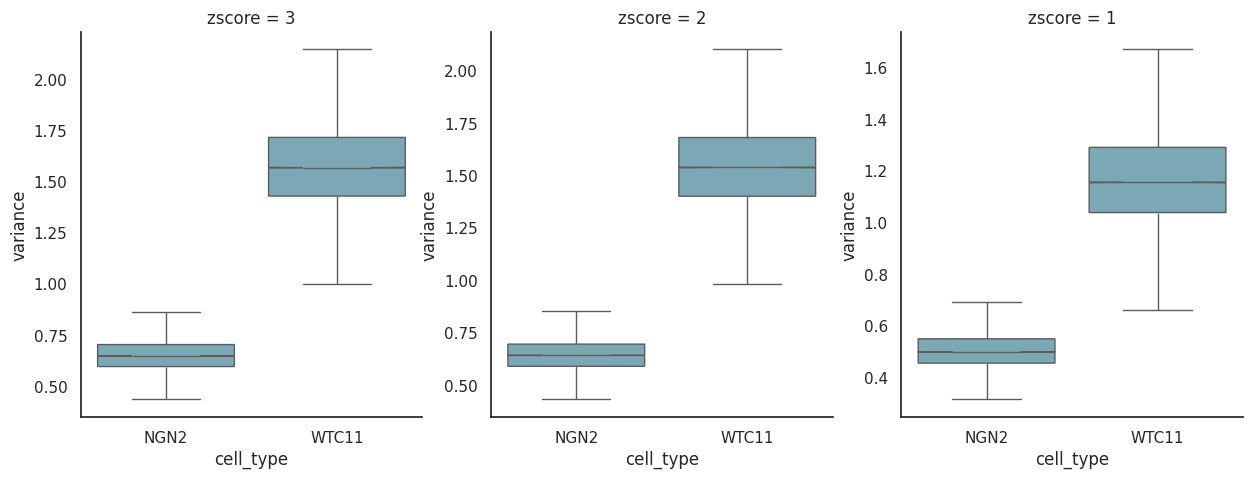

In [ ]:
cell_variance_box_plot([reshaped_celltyp_variance_z_3,
                        reshaped_celltyp_variance_z_2,
                        reshaped_celltyp_variance_z_1],
                       
                       ['zscore = 3', 'zscore = 2', 'zscore = 1'])

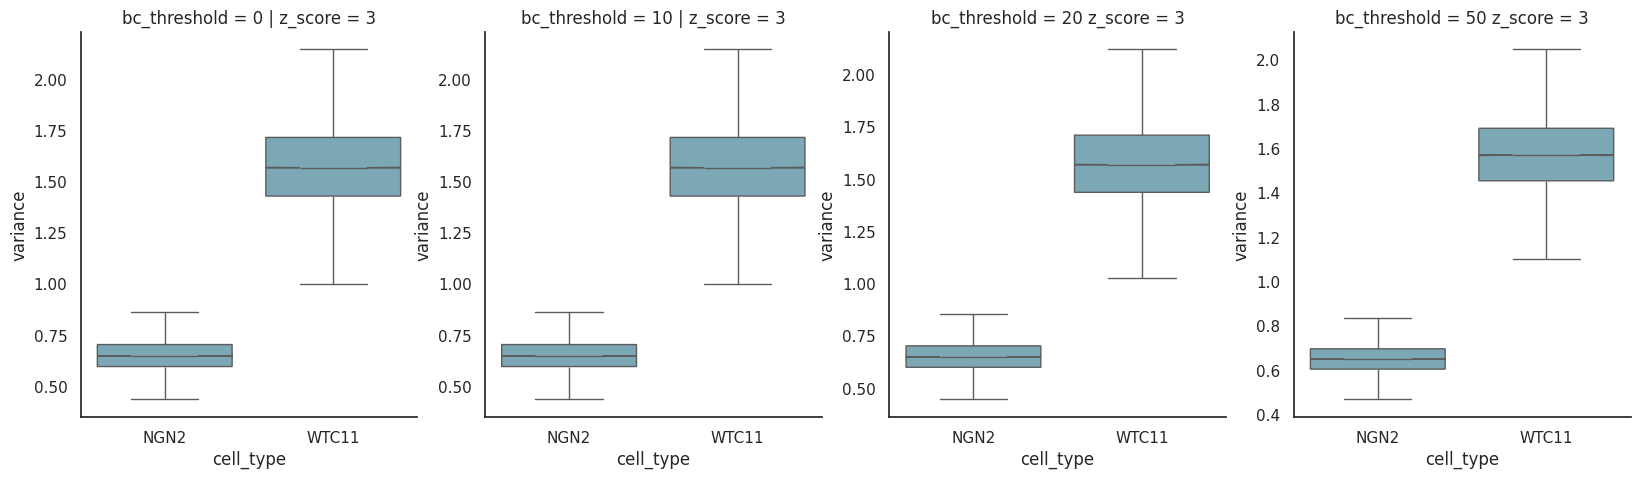

In [78]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_3,
                        reshaped_celltyp_variance_bc_10_z_3,
                        reshaped_celltyp_variance_bc_20_z_3,
                        reshaped_celltyp_variance_bc_50_z_3],
                       
                       ['bc_threshold = 0 | z_score = 3','bc_threshold = 10 | z_score = 3', 'bc_threshold = 20 z_score = 3', 'bc_threshold = 50 z_score = 3'])

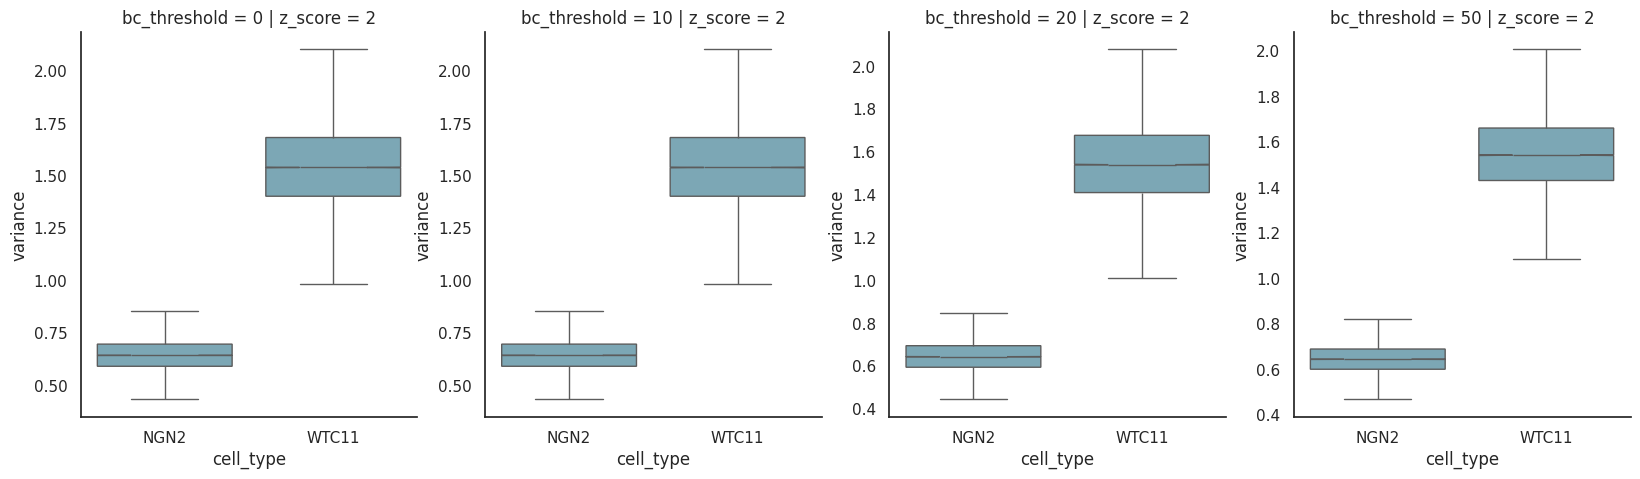

In [79]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_2,
                        reshaped_celltyp_variance_bc_10_z_2,
                        reshaped_celltyp_variance_bc_20_z_2,
                        reshaped_celltyp_variance_bc_50_z_2],
                       
                       ['bc_threshold = 0 | z_score = 2','bc_threshold = 10 | z_score = 2', 'bc_threshold = 20 | z_score = 2', 'bc_threshold = 50 | z_score = 2'])

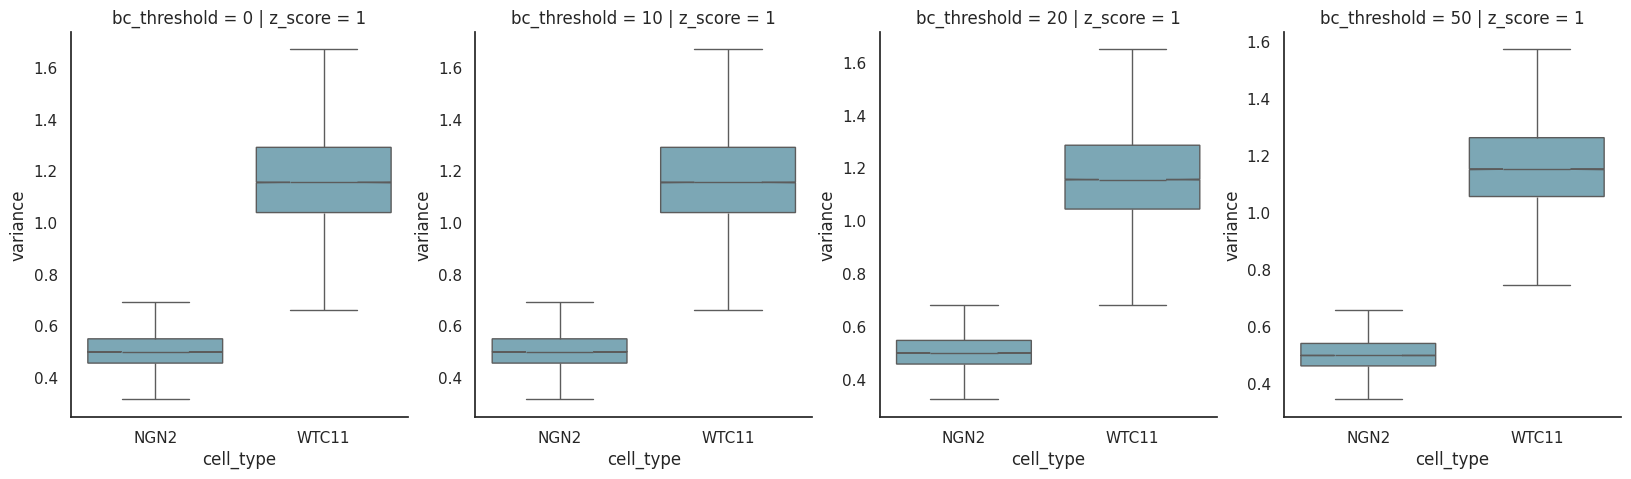

In [32]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_1,
                        reshaped_celltyp_variance_bc_10_z_1,
                        reshaped_celltyp_variance_bc_20_z_1,
                        reshaped_celltyp_variance_bc_50_z_1],
                       
                       ['bc_threshold = 0 | z_score = 1','bc_threshold = 10 | z_score = 1', 'bc_threshold = 20 | z_score = 1', 'bc_threshold = 50 | z_score = 1'])

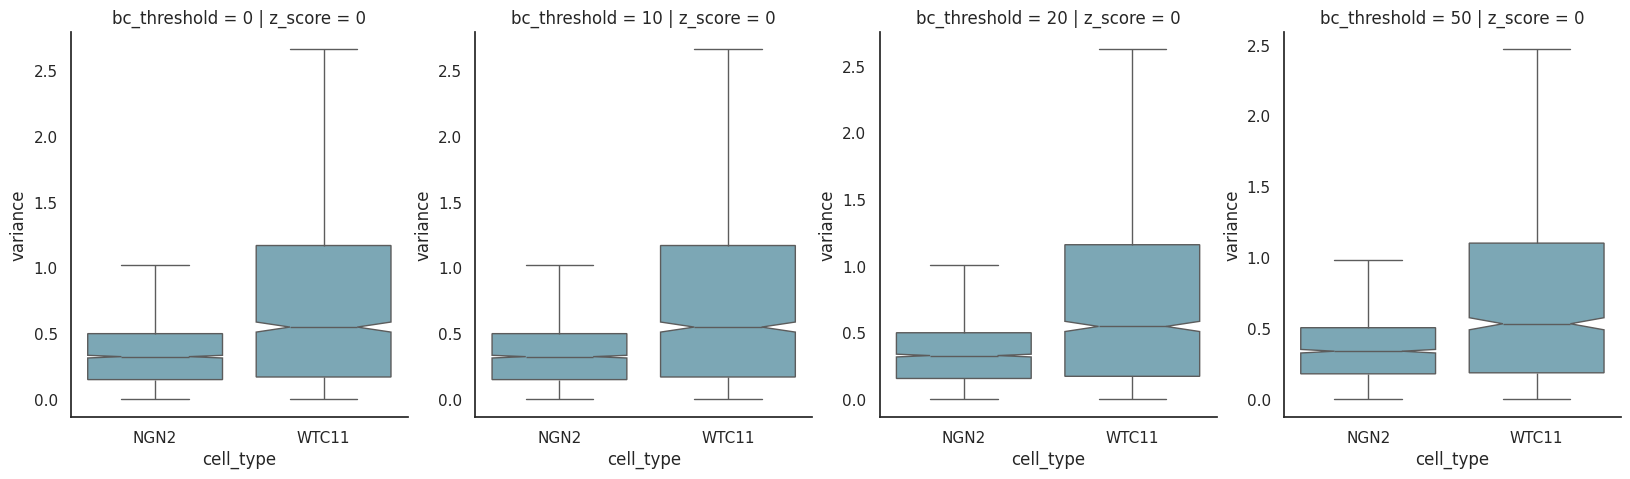

In [95]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_0,
                        reshaped_celltyp_variance_bc_10_z_0,
                        reshaped_celltyp_variance_bc_20_z_0,
                        reshaped_celltyp_variance_bc_50_z_0],
                       
                       ['bc_threshold = 0 | z_score = 0','bc_threshold = 10 | z_score = 0', 'bc_threshold = 20 | z_score = 0', 'bc_threshold = 50 | z_score = 0'])

In [102]:
len(reshaped_celltyp_mean_bc_0_z_3) == len(reshaped_celltyp_mean_bc_0_z_0)

False

In [104]:
len(reshaped_celltyp_mean_bc_0_z_3)

155918

In [105]:
oligos_z3 = set(
    reshaped_celltyp_mean_bc_0_z_3["oligo_name"]
)

oligos_z0 = set(
    reshaped_celltyp_mean_bc_0_z_0["oligo_name"]
)

removed_in_z0 = oligos_z3 - oligos_z0

print(len(removed_in_z0))

14


In [54]:
reshaped_celltyp_variance_bc_0_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_0_z_1.tsv.gz')
reshaped_celltyp_variance_bc_10_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_10_z_1.tsv.gz')
reshaped_celltyp_variance_bc_20_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_20_z_1.tsv.gz')
reshaped_celltyp_variance_bc_50_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_50_z_1.tsv.gz')

In [37]:
reshaped_celltyp_variance_bc_0_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_0_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_10_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_10_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_20_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_20_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_50_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_50_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)

In [43]:
reshaped_celltyp_variance_bc_0_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_0_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_10_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_10_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_20_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_20_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_50_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_50_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)

In [61]:
def calculate_common_non_outlier_bounds(
    data_table: pd.DataFrame
) -> tuple[float, float]:

    non_outlier_ranges = {}

    for cell_type, group in data_table.groupby("cell_type"):
        variance = group["variance"].dropna()

        q1 = variance.quantile(0.25)
        q3 = variance.quantile(0.75)
        iqr = q3 - q1

        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr

        non_outliers = variance.between(lower_fence, upper_fence)

        non_outlier_ranges[cell_type] = (
            variance[non_outliers].min(),
            variance[non_outliers].max()
        )

    lower_bound = max(
        interval[0] for interval in non_outlier_ranges.values()
    )

    upper_bound = min(
        interval[1] for interval in non_outlier_ranges.values()
    )

    return lower_bound, upper_bound

In [62]:
lower_bound, upper_bound = calculate_common_non_outlier_bounds(reshaped_celltyp_variance_bc_0_z_1)
lower_bound, upper_bound

(np.float64(0.66103566), np.float64(0.69107956))

In [77]:
similar_variance = reshaped_celltyp_variance_bc_0_z_1[reshaped_celltyp_variance_bc_0_z_1['variance'].between(lower_bound, upper_bound)].reset_index(drop = True)

In [78]:
len(similar_variance)

1422

In [73]:
variant_ref_alt_element_metrics_NGN2_WTC11 = pd.read_table('data/results/merge_elements/variant_ref_alt_element_metrics_NGN2_WTC11.tsv.gz')

In [74]:
variant_ref_alt_element_metrics_NGN2_WTC11.head()

,variant_id,logFC_NGN2,variant_effect_NGN2,adj.P.Val_NGN2,significant_NGN2,sig_category_NGN2,variant_effect_WTC11,logFC_WTC11,adj.P.Val_WTC11,significant_WTC11,...,dna_count_2_ALT_WTC11,dna_count_3_ALT_WTC11,rna_count_1_ALT_WTC11,rna_count_2_ALT_WTC11,rna_count_3_ALT_WTC11,unique_barcode_count_ALT_WTC11,label_ALT,effect_size_ALT_WTC11,norm_effect_size_ALT_WTC11,adj.P.Value_ALT_WTC11
0,C_positive_heart_CAD:ALT_rs1037169_rs1037169,-0.010908,NaN,0.987905,False,not_significant,NaN,NaN,NaN,NaN,...,353.0,332.0,671.0,884.0,952.0,53.0,C_positive_heart_CAD,0.094808,0.360180,1.0
1,C_positive_heart_CAD:ALT_rs1051338_rs1051338,-0.055394,-0.000419,0.882584,False,not_significant,-0.043954,-0.099785,0.932064,False,...,643.0,576.0,1167.0,1178.0,1379.0,129.0,C_positive_heart_CAD,-0.035234,0.005209,1.0
2,C_positive_heart_CAD:ALT_rs10750098_rs10750098,0.090207,NaN,0.905374,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_positive_heart_CAD:ALT_rs10774625_rs10774625,0.220865,NaN,0.381383,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C_positive_heart_CAD:ALT_rs10811656_rs10811656,0.060657,NaN,0.900026,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
selected_oligos = set(similar_variance["oligo_name"])
variant_qc = variant_ref_alt_element_metrics_NGN2_WTC11[variant_ref_alt_element_metrics_NGN2_WTC11['oligo_name_REF'].isin(selected_oligos)
                                                        & variant_ref_alt_element_metrics_NGN2_WTC11['oligo_name_ALT'].isin(selected_oligos)]

In [81]:
len(variant_qc)

6

Barcode outlier filtering reduces the overall variance, particularly at z-score = 1, but does not eliminate the variance difference between NGN2 and WTC11.